# Part 3 — Contextual bandits: your first regime-aware selector

**Analogy.** A plain bandit asks "which umbrella policy is best on average?". A contextual
bandit **looks out of the window first**: "it's cloudy, so take the umbrella". Same choices,
but the best choice now depends on what you observe.

**Our problem.** Every Monday the agent sees a **context vector** x (IV rank, VIX level, term
structure, trend, realised-vs-implied vol, days to earnings, last week's return) and picks a
strategy. It learns a separate estimate for each strategy that **depends on x**:

$$ \hat Q(x, a) \approx \text{expected P\&L of strategy } a \text{ when the market looks like } x $$

It's still a bandit, because each week's decision doesn't affect next week's market or position.
(That changes in Part 4.)

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import optrl
from optrl import metrics as M
M.set_style()
market = optrl.load_default_market()
table = optrl.weekly_pnl_table(market)
X = optrl.decision_features(market, table)
regime = market.df.loc[table.index, "regime_name"]
A = optrl.ACTION_NAMES
n = len(table); cut = int(n * 0.7)                 # first 70% = "past", last 30% = "future"
print(f"{n} weeks: train {table.index[0].date()} → {table.index[cut-1].date()}, test → {table.index[-1].date()}")
X.describe().T[["mean", "std", "min", "max"]].round(2)

1007 weeks: train 2006-01-02 → 2019-06-24, test → 2025-04-14


,mean,std,min,max
vix,18.03,4.80,11.83,40.26
iv_rank,31.67,24.70,0.00,100.00
term_structure,0.93,0.06,0.83,1.15
ema_trend,-0.06,1.34,-8.20,3.74
rv_iv_spread,-1.95,6.39,-15.35,35.83
days_to_earnings,31.17,18.36,0.00,63.00
ret_5d,0.03,2.68,-14.28,18.52


---
## 3.1 Feature engineering: turning market data into a context vector

**Analogy.** A weather forecaster doesn't feed raw satellite pixels to her gut. She summarises
them as "pressure falling, humidity 80%". Good features are **compact summaries that relate to
what makes each strategy win**.

| Feature | Why a vol trader cares | Which strategies it should favour |
|---|---|---|
| `vix` level | the price of options | high → sell premium (if not a shock); low → debit spreads are cheap |
| `iv_rank` | is IV rich *relative to its own history*? | high rank → premium selling |
| `term_structure` (VIX/VIX3M) | > 1 means near-term fear: stress | backwardation → long vol, bearish |
| `ema_trend` (EMA9 − EMA20) | direction | up → bull spreads; down → bear spreads |
| `rv_iv_spread` (RV − IV) | are options cheap or rich vs realised moves? | > 0 → long vol; < 0 → short vol |
| `days_to_earnings` | gap risk inside the option's life | ≤ 5 → sit out or go long vol |
| `ret_5d` | last week's move, momentum or mean reversion | directional tilt |

### Standardisation (z-scores)
Features live on different scales (VIX ≈ 18, term structure ≈ 0.93). Linear models behave
much better when each feature is rescaled to mean 0 and std 1:

$$ z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}} $$

*Worked example.* Train-period VIX has μ = 18.0 and σ = 5.0. On our scenario Monday VIX = 13.5:
z = (13.5 − 18.0)/5.0 = **−0.9**, "about one std below normal".

⚠️ **Use the *training* period's μ and σ only.** Computing them over the full history leaks
future information (the model would "know" the future average VIX). It's a subtle form of
look-ahead bias.

In [2]:
mu, sd = X.iloc[:cut].mean(), X.iloc[:cut].std()
Z = ((X - mu) / sd).clip(-5, 5)
Z.insert(0, "bias", 1.0)                           # constant term = the arm's baseline P&L
print("z-scored context for the first Monday:\n", Z.iloc[0].round(2).to_dict())

z-scored context for the first Monday:
 {'bias': 1.0, 'vix': 0.29, 'iv_rank': -0.15, 'term_structure': 0.14, 'ema_trend': -0.88, 'rv_iv_spread': -0.15, 'days_to_earnings': -0.88, 'ret_5d': -0.15}


---
## 3.2 A linear model per strategy

The simplest context-aware estimate is **one linear model per strategy**:

$$ \hat Q(x, a) = \theta_a^\top x = \theta_{a,0} + \theta_{a,1} x_1 + \dots + \theta_{a,d} x_d $$

*In words:* each strategy has a baseline P&L θ₀ plus a sensitivity to each feature.

*Worked example.* Say the long straddle has θ = [−0.20, +0.25 (term_structure), +0.10 (rv_iv_spread)]
(in \$1000s). In a stress week with term_structure z = +2 and rv_iv_spread z = +1.5:
Q̂ = −0.20 + 0.25·2 + 0.10·1.5 = **+0.45** → about +\$450 expected, so buy it. In a calm week
(z = −1, −0.5): Q̂ = −0.20 − 0.25 − 0.05 = **−0.50**, so avoid it.

### Fitting with ridge regression
If you know every strategy's P&L for past weeks (you do, in a backtest!), each θ_a is a
regression:

$$ \theta_a = (X^\top X + \lambda I)^{-1} X^\top r_a $$

The λI term ("ridge") shrinks θ toward 0 so noise doesn't produce wild coefficients.

### 🛠 Exercise 3.2: full-information selector (= supervised learning)
Fit ridge (λ = 1) for every action on the **train** weeks, using `Z` as inputs and `table/1000`
as targets. On the **test** weeks, pick the action with the highest predicted Q. Report the
average P&L per week, and compare it with (a) the best single strategy chosen on train and
(b) the hindsight regime oracle (best strategy per hidden regime, known from train).

*Expected:* the linear selector clearly beats the best single strategy on the test period.
The regime oracle, which cheats by seeing the hidden regime, is the ceiling.

In [3]:
Zt, R = Z.to_numpy(), table.to_numpy() / 1000
def fit_ridge(Zm, Rm, lam=1.0):
    # TODO: return Theta with shape (n_features, n_actions)
    return None

**Solution**

In [4]:
def fit_ridge(Zm, Rm, lam=1.0):
    d = Zm.shape[1]
    return np.linalg.solve(Zm.T @ Zm + lam * np.eye(d), Zm.T @ Rm)

Theta = fit_ridge(Zt[:cut], R[:cut])
choice_full = (Zt[cut:] @ Theta).argmax(1)
test = np.arange(cut, n)
best_single = int(R[:cut].mean(0).argmax())
oracle_map = table.iloc[:cut].groupby(regime.iloc[:cut]).mean().idxmax(axis=1)
oracle_choice = [A.index(oracle_map[g]) for g in regime.iloc[cut:]]

scores = pd.Series({
    f"best single on train ({A[best_single]})": R[cut:, best_single].mean(),
    "linear selector (full info)": R[test, choice_full].mean(),
    "regime oracle (cheats)": R[test, oracle_choice].mean(),
}) * 1000
print(scores.round(1).to_string())

best single on train (bull_put_spread)     46.2
linear selector (full info)                71.7
regime oracle (cheats)                    101.9


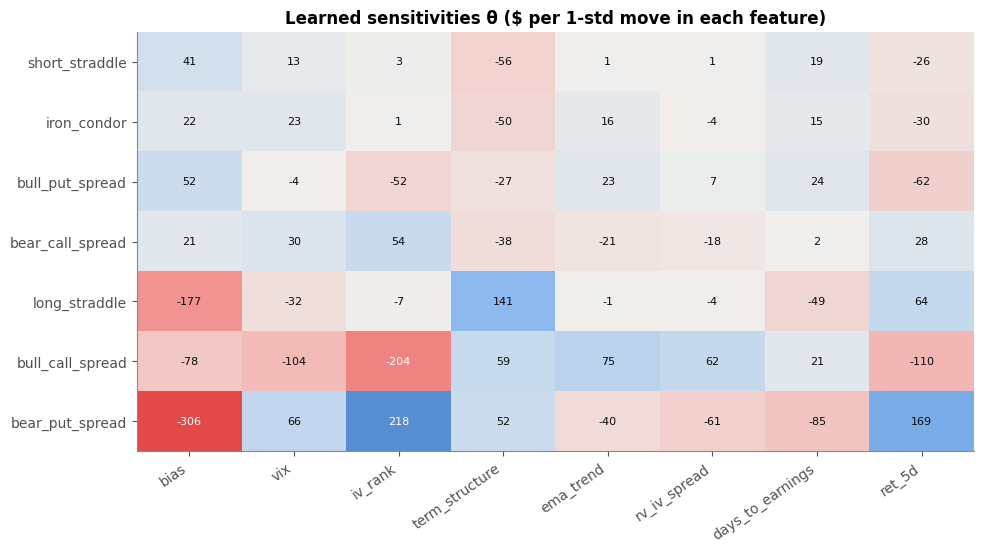

In [5]:
coef = pd.DataFrame(Theta * 1000, index=Z.columns, columns=A).drop(columns="no_trade")
M.plot_value_heatmap(coef.T, "Learned sensitivities θ ($ per 1-std move in each feature)")
plt.show()

**Read the coefficients like a trader.** They should make economic sense. If they don't,
suspect a bug, noise or overfitting.
* `term_structure` ↑ (stress): the long straddle goes strongly **up** and short-vol trades go
  **down**. ✓
* `ema_trend` ↑ (uptrend): bull spreads go **up** and bear spreads go **down**. ✓
* `ret_5d` has a large *positive* weight for the bear put spread, while `ema_trend` has a
  negative one. Both measure recent direction, so opposite signs are a red flag. This is
  **collinearity**: the model splits credit between two similar features, and each coefficient
  on its own isn't trustworthy (only their combined effect is). Remedies: a larger ridge λ,
  or drop one of the pair.

Economic sanity checks like these are one of your best defences against fooling yourself.

---
## 3.3 The bandit catch: live, you only see what you traded

The exercise above used the **full** backtest table: every strategy's P&L every week. Live, you
only observe the P&L of the strategy you actually deployed (**bandit feedback**). So each
strategy's model only learns from the weeks when it was chosen, and you still need
exploration, now **per context**.

### LinUCB: UCB for linear models
For each strategy keep $A_a = \lambda I + \sum x x^\top$ (what you've seen) and
$b_a = \sum r\,x$ (what it paid). Then

$$ \theta_a = A_a^{-1} b_a, \qquad \text{score}_a(x) = \underbrace{\theta_a^\top x}_{\text{estimate}} + \alpha \underbrace{\sqrt{x^\top A_a^{-1} x}}_{\text{uncertainty in this context}} $$

*In words:* same as UCB, but the uncertainty is **specific to the current market**. If you've
traded the long straddle 50 times in calm markets but never in backwardation, its uncertainty
is small for calm contexts and **large for stress contexts**, so it gets explored exactly where
you know little.

*Worked example (1 feature + bias).* The long straddle has only been tried in calm weeks with
x = [1, −1] (bias, term structure z). After 10 such weeks, A = I + 10·[[1,−1],[−1,1]].
That's A = [[11, −10], [−10, 11]], and $A^{-1} = \tfrac{1}{21}[[11, 10], [10, 11]]$.
For a calm context x = [1, −1]: $x^\top A^{-1} x = 2/21 ≈ 0.095$, bonus = α·√0.095 = α·0.31.
For a stress context x = [1, +2]: $x^\top A^{-1} x = 95/21 ≈ 4.52$, bonus = α·2.13, **about 7× bigger**.
The agent is appropriately curious about straddles in stress.

In [6]:
Aex = np.eye(2) + 10 * np.outer([1, -1], [1, -1])
for lab, x in [("calm x=[1,-1]", np.array([1, -1])), ("stress x=[1,+2]", np.array([1, 2]))]:
    print(lab, "x'A^-1x =", round(float(x @ np.linalg.inv(Aex) @ x), 3))

calm x=[1,-1] x'A^-1x = 0.095
stress x=[1,+2] x'A^-1x = 4.524


In [7]:
class LinUCB:
    """Disjoint LinUCB: one ridge model per action, with an uncertainty bonus."""

    def __init__(self, n_actions, n_features, alpha=0.5, lam=1.0):
        self.alpha = alpha
        self.Ainv = np.array([np.eye(n_features) / lam for _ in range(n_actions)])
        self.b = np.zeros((n_actions, n_features))

    def scores(self, x, explore=True):
        theta = np.einsum("aij,aj->ai", self.Ainv, self.b)          # θ_a = A_a^-1 b_a
        est = theta @ x
        if not explore:
            return est
        bonus = np.sqrt(np.einsum("i,aij,j->a", x, self.Ainv, x))
        return est + self.alpha * bonus

    def select(self, x, explore=True):
        return int(np.argmax(self.scores(x, explore)))

    def update(self, x, a, r):
        Ai = self.Ainv[a]                                           # Sherman-Morrison: cheap
        u = Ai @ x                                                  # rank-1 update of A^-1
        self.Ainv[a] = Ai - np.outer(u, u) / (1.0 + x @ u)
        self.b[a] += r * x

### An expert's twist: in options you often *can* see the other arms

In textbook bandits (showing ads, say) you truly never learn what the other choices would have
done. **Strategy selection is different.** On Friday you can take the option chain and compute
what the iron condor you *didn't* trade would have made. That's "shadow" or paper P&L. For
liquid, listed strategies, the counterfactual rewards are **observable**, up to fill
assumptions. So you can update *every* strategy's model every week: a **full-information**
contextual bandit, which is really online supervised learning.

Exploration is still needed for what you **can't** simulate: your real fills and slippage, and
a strategy whose P&L depends on your own discretionary management. The rule of thumb:

> **Use shadow P&L wherever it's trustworthy, and spend real exploration only on what it can't tell you.**

---
## 3.4 Project: the first regime-aware selector

We replay the 20 years **in time order**, as you would have traded it. Every agent starts
knowing nothing. We score them on the **test** period (the last 30%), by which point each has
had 14 years to learn.

1. **UCB, no context** (Part 2): online, bandit feedback.
2. **LinUCB**: online, bandit feedback, sees the features.
3. **Online ridge with shadow P&L**: online, full information (updates every strategy's model
   each week), greedy.
4. **Hindsight single best**: a benchmark you couldn't know in advance.

In [8]:
def run_ucb(R, c=0.1):
    k = R.shape[1]; Q = np.zeros(k); N = np.zeros(k); ch = np.zeros(len(R), int)
    for t in range(len(R)):
        a = t if t < k else int(np.argmax(Q + c * np.sqrt(np.log(t + 1) / N)))
        ch[t] = a; N[a] += 1; Q[a] += (R[t, a] - Q[a]) / N[a]
    return ch

def run_linucb(Zm, R, alpha=0.5, full_info=False):
    """full_info=True → update every action's model each week (shadow P&L), act greedily."""
    agent = LinUCB(R.shape[1], Zm.shape[1], alpha=alpha)
    ch = np.zeros(len(R), int)
    for t in range(len(R)):
        a = agent.select(Zm[t], explore=not full_info); ch[t] = a
        for aa in (range(R.shape[1]) if full_info else [a]):
            agent.update(Zm[t], aa, R[t, aa])
    return ch, agent

ch_ucb = run_ucb(R)
ch_lin, _ = run_linucb(Zt, R, alpha=0.5)
ch_full, full_agent = run_linucb(Zt, R, full_info=True)
hind = int(R[cut:].mean(0).argmax())

idx = np.arange(n)
pnl = pd.DataFrame({
    "UCB (no context)": R[idx, ch_ucb],
    "LinUCB (bandit feedback)": R[idx, ch_lin],
    "Online ridge (shadow P&L)": R[idx, ch_full],
    f"hindsight: always {A[hind]}": R[:, hind],
}, index=table.index) * 1000

summary = pd.DataFrame({c: M.summarize(pnl[c].iloc[cut:]) for c in pnl}).T
print("TEST PERIOD (last 30%) on the default market:"); print(summary.round(2).to_string())

TEST PERIOD (last 30%) on the default market:
                                  total_pnl  mean_per_period  sharpe  max_drawdown  cvar_5%  win_rate
UCB (no context)                   -3666.51           -12.10   -0.50       4603.47  -632.82      0.70
LinUCB (bandit feedback)           16572.65            54.70    1.29       3842.59  -927.93      0.82
Online ridge (shadow P&L)          26675.71            88.04    0.83       4371.59 -1092.41      0.70
hindsight: always short_straddle   17514.71            57.80    1.55       2975.38  -679.11      0.69


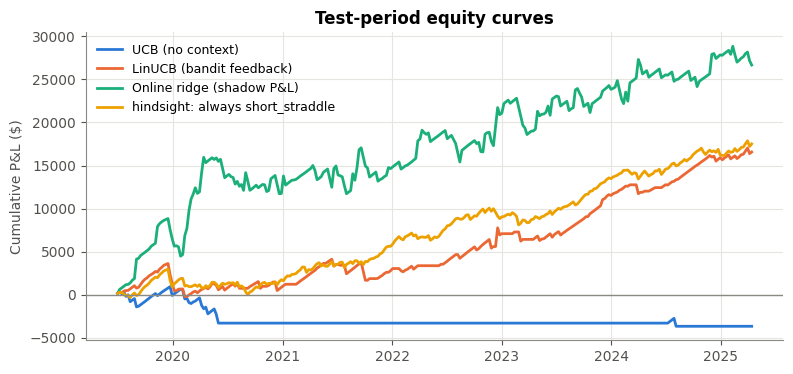

In [9]:
M.plot_equity({c: pnl[c].iloc[cut:] for c in pnl}, title="Test-period equity curves")
plt.show()

**Why does UCB's line go flat?** It is "exploring" `no_trade`. UCB gives every rarely-tried arm
a big uncertainty bonus, but `no_trade`'s value is *known* to be exactly \$0. It has no
uncertainty at all. So UCB wastes months sitting in cash to "learn" something it already knew.
The fix is simple: give known-value actions no bonus (treat their N as infinite). **Put what you
know into the algorithm.** Generic methods don't know which of your actions are deterministic.

### One market path is one anecdote: check many worlds
A single 6-year test period is **one draw** of history. Luck matters a lot, as you saw in
Part 2. The simulator lets us do something you can't do with real data: replay the whole
experiment on 10 different simulated histories. (Part 8 turns this into a habit.)

In [10]:
def experiment(seed):
    m = optrl.simulate_market(seed=seed)
    tb = optrl.weekly_pnl_table(m); Xs = optrl.decision_features(m, tb)
    c = int(len(tb) * 0.7)
    Zs = ((Xs - Xs.iloc[:c].mean()) / Xs.iloc[:c].std()).clip(-5, 5); Zs.insert(0, "bias", 1.0)
    Zs, Rs = Zs.to_numpy(), tb.to_numpy() / 1000
    ii = np.arange(c, len(Rs))
    return {"UCB (no context)": Rs[ii, run_ucb(Rs)[c:]].mean(),
            "LinUCB (bandit feedback)": Rs[ii, run_linucb(Zs, Rs, 0.5)[0][c:]].mean(),
            "Online ridge (shadow P&L)": Rs[ii, run_linucb(Zs, Rs, full_info=True)[0][c:]].mean(),
            "hindsight single best": Rs[c:].mean(0).max()}

worlds = pd.DataFrame([experiment(s) for s in range(10)]) * 1000
print("Test-period $/week in 10 simulated worlds:")
print(worlds.round(0).to_string())
print("\nmean:", worlds.mean().round(1).to_dict())
print("ridge beats hindsight-single in", (worlds["Online ridge (shadow P&L)"] > worlds["hindsight single best"]).sum(), "of 10 worlds")

Test-period $/week in 10 simulated worlds:
   UCB (no context)  LinUCB (bandit feedback)  Online ridge (shadow P&L)  hindsight single best
0              32.0                      71.0                       30.0                   52.0
1             -12.0                      55.0                       88.0                   58.0
2              26.0                      69.0                      133.0                   77.0
3              34.0                      92.0                       72.0                   56.0
4              16.0                      54.0                       77.0                   48.0
5              37.0                      82.0                      145.0                   34.0
6              76.0                     120.0                      137.0                   77.0
7              64.0                      16.0                      106.0                   64.0
8             -11.0                     -14.0                       32.0                   24

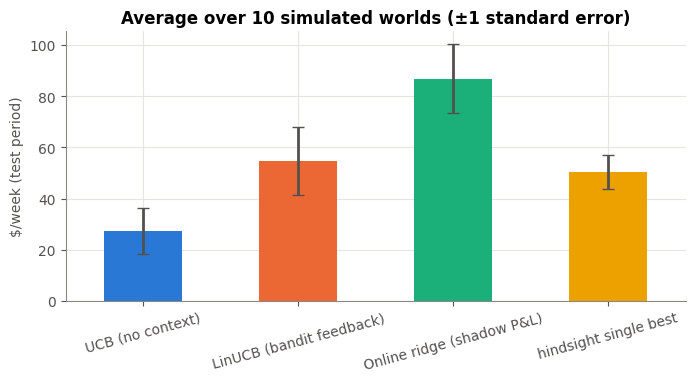

In [11]:
ax = worlds.mean().plot.bar(yerr=worlds.std() / np.sqrt(len(worlds)), color=[M.PALETTE[i] for i in range(4)],
                            figsize=(8, 3.5), rot=15, capsize=4)
ax.set_ylabel("$/week (test period)"); ax.set_title("Average over 10 simulated worlds (±1 standard error)"); plt.show()

**What the results say** (this pattern holds across worlds, even though single worlds are noisy):
* **Context pays, but only if you can learn it cheaply.** LinUCB with bandit feedback has to
  *trade* each strategy in each kind of market to learn about it. In options, exploration
  means real losing trades in the expensive debit strategies. So it only roughly matches the
  hindsight single strategy.
* **Online ridge with shadow P&L wins clearly.** It sees every strategy's outcome every week,
  so it learns "which strategy when" with no exploration cost. It beats even the hindsight
  single-best strategy on average.
* The hindsight single strategy is a **benchmark**, not something you could have traded: you
  only learn which one it was after the fact.

### Did it learn the regimes? The strategy-selection heatmap
The agent never saw the hidden regime. If it learned sensible behaviour, its choices should
still **line up with the regimes**.

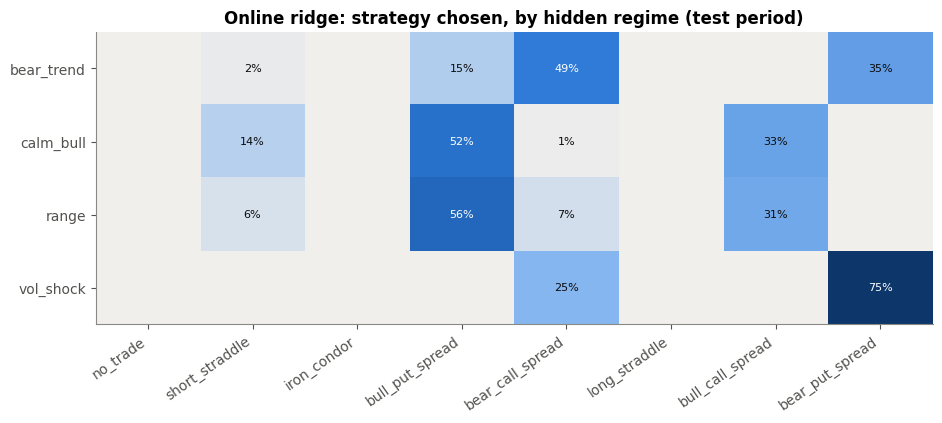

In [12]:
sel = pd.DataFrame({"regime": regime.iloc[cut:].values, "action": np.array(A)[ch_full[cut:]]})
M.plot_selection_heatmap(sel, row="regime", title="Online ridge: strategy chosen, by hidden regime (test period)")
plt.show()

A good picture shows bullish trades concentrated in **calm_bull**, premium selling in
**range**, bearish trades in **bear_trend**, and long straddles or bear put spreads in
**vol_shock**. The rows won't be pure, because the features only *partially* reveal the regime.

### Back to the Monday scenario
> *Monday. VIX between 13 and 14. EMA9 < EMA20. What does the agent pick, and why?*

Take the last matching Monday **without earnings inside the week**. Train the full-information
agent on everything *before* that date, then ask it.

In [13]:
d = market.df.loc[table.index]
match = np.flatnonzero((d.vix.between(13, 14) & (d.ema9 < d.ema20) & (d.days_to_earnings > 5)).to_numpy())
t0 = match[-1]
_, agent_t0 = run_linucb(Zt[:t0], R[:t0], full_info=True)           # knows only the past
print("Scenario Monday:", table.index[t0].date(), "| hidden regime (for us, not the agent):", regime.iloc[t0])
print(X.iloc[t0].round(2).to_dict())
est = pd.Series(agent_t0.scores(Zt[t0], explore=False) * 1000, index=A).sort_values(ascending=False)
print("\nAgent's estimated P&L ($) per strategy:\n", est.round(0).to_string())
pick = A.index(est.index[0])
theta = agent_t0.Ainv[pick] @ agent_t0.b[pick]
print(f"\nWhy {est.index[0]}? Contribution of each feature ($):\n",
      pd.Series(theta * Zt[t0] * 1000, index=Z.columns).round(0).to_string())
print(f"\nWhat actually happened that week: {table.iloc[t0].round(0).to_dict()}")

Scenario Monday: 2024-10-21 | hidden regime (for us, not the agent): calm_bull
{'vix': 13.97, 'iv_rank': 6.54, 'term_structure': 0.88, 'ema_trend': -0.04, 'rv_iv_spread': -5.29, 'days_to_earnings': 24.0, 'ret_5d': -0.63}

Agent's estimated P&L ($) per strategy:
 bull_call_spread    142.0
bull_put_spread     129.0
short_straddle       69.0
iron_condor          45.0
no_trade              0.0
bear_call_spread    -27.0
long_straddle      -250.0
bear_put_spread    -578.0

Why bull_call_spread? Contribution of each feature ($):
 bias               -109.0
vix                  96.0
iv_rank             178.0
term_structure      -31.0
ema_trend             1.0
rv_iv_spread        -20.0
days_to_earnings     -1.0
ret_5d               28.0

What actually happened that week: {'no_trade': 0.0, 'short_straddle': 117.0, 'iron_condor': 114.0, 'bull_put_spread': 170.0, 'bear_call_spread': 142.0, 'long_straddle': -376.0, 'bull_call_spread': 593.0, 'bear_put_spread': -1088.0}


**Interpretation.** Low VIX, low IV rank and contango say *calm*. The mild downtrend
(EMA9 < EMA20) is only one input, and the agent weighs it against the others. It doesn't jump
to a bear spread just because the short-term trend dipped. Reading the per-feature
**contributions** is how you explain a decision to a risk manager, and it's a big advantage of
linear models. Whatever happened that particular week is a single noisy draw. Judge the
*process*, not one outcome.

---
### 🛠 Exercise 3.4a: tune exploration, robustly
Run LinUCB (bandit feedback) with α ∈ {0.1, 0.5, 1.0} on 5 simulated worlds (seeds 0–4, reuse
the logic in `experiment`), and report the average test-period \$/week for each α.

*Expected:* α = 0.5 does best on average. Too little exploration locks in early mistakes, and
too much keeps trading losing debit spreads "to learn". In any *single* world the ranking can
flip, which is exactly why you average.

In [14]:
# TODO

**Solution**

In [15]:
def linucb_world(seed, alpha):
    m = optrl.simulate_market(seed=seed)
    tb = optrl.weekly_pnl_table(m); Xs = optrl.decision_features(m, tb); c = int(len(tb) * 0.7)
    Zs = ((Xs - Xs.iloc[:c].mean()) / Xs.iloc[:c].std()).clip(-5, 5); Zs.insert(0, "bias", 1.0)
    Rs = tb.to_numpy() / 1000
    ch, _ = run_linucb(Zs.to_numpy(), Rs, alpha)
    return Rs[np.arange(c, len(Rs)), ch[c:]].mean() * 1000

for alpha in [0.1, 0.5, 1.0]:
    vals = [linucb_world(s, alpha) for s in range(5)]
    print(f"α={alpha:<4}: mean ${np.mean(vals):6.1f}/week   per world: {np.round(vals, 0)}")

α=0.1 : mean $  58.1/week   per world: [43. 47. 79. 55. 66.]


α=0.5 : mean $  68.3/week   per world: [71. 55. 69. 92. 54.]


α=1.0 : mean $  32.5/week   per world: [20. 31. 49. 23. 40.]


### 🛠 Exercise 3.4b: feature ablation. Which features matter?
Retrain the **online ridge** agent while dropping one feature at a time, and record the drop in
test-period \$/week on the default market.

*Expected:* the ranking is **less obvious than intuition suggests.** VIX, IV rank, term
structure and RV−IV all measure "stress" in overlapping ways. Remove one and another takes over,
so the drop measures only the feature's **unique** information. The vol-pricing features
(`rv_iv_spread`, `iv_rank`, `vix`) tend to matter most. Removing some features (like `ret_5d`)
can even *help* a little, because a useless feature only adds noise. A single-market ablation is
itself noisy, so confirm across worlds before you delete anything.

In [16]:
# TODO

**Solution**

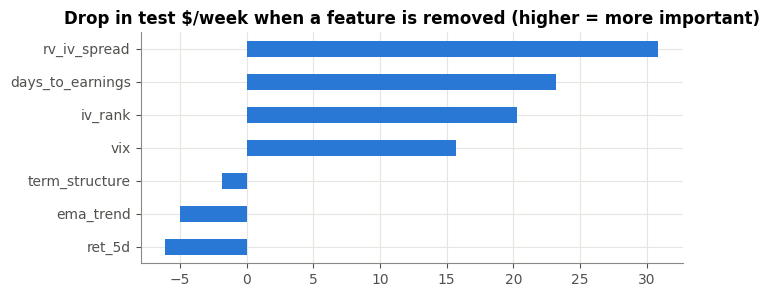

In [17]:
base = R[test, ch_full[cut:]].mean() * 1000
rows = {}
for f in optrl.MarketData.FEATURES:
    ch, _ = run_linucb(Z.drop(columns=f).to_numpy(), R, full_info=True)
    rows[f] = base - R[test, ch[cut:]].mean() * 1000
imp = pd.Series(rows).sort_values()
ax = imp.plot.barh(color=M.PALETTE[0], figsize=(7, 3))
ax.set_title("Drop in test $/week when a feature is removed (higher = more important)"); plt.show()

### 🛠 Exercise 3.4c: test a trader's intuition
"Never sell premium into earnings" is folk wisdom. The linear model can't express "earnings is
*inside* the option's life", because risk isn't linear in `days_to_earnings`. Add a binary
feature `earn_week = 1 if 1 ≤ days_to_earnings ≤ 5`, then compare the online ridge agent with
and without it, **averaged over 10 worlds**.

*Expected (and instructive):* **no reliable improvement.** Earnings weeks are only ~8% of the
data, and their average effect is small (Part 1 showed all strategies at −\$6 to −\$120 in
those weeks). One extra coefficient per strategy adds about as much noise as signal. The
lesson: **validate intuition with data, averaged over enough samples, before adding
complexity.** Part 5's tabular agent and Part 7's neural nets can capture this kind of
interaction more naturally.

In [18]:
# TODO

**Solution**

In [19]:
def ridge_world(seed, add_earn):
    m = optrl.simulate_market(seed=seed)
    tb = optrl.weekly_pnl_table(m); Xs = optrl.decision_features(m, tb); c = int(len(tb) * 0.7)
    Zs = ((Xs - Xs.iloc[:c].mean()) / Xs.iloc[:c].std()).clip(-5, 5); Zs.insert(0, "bias", 1.0)
    if add_earn:
        Zs["earn_week"] = Xs.days_to_earnings.between(1, 5).astype(float)
    Rs = tb.to_numpy() / 1000
    ch, _ = run_linucb(Zs.to_numpy(), Rs, full_info=True)
    return Rs[np.arange(c, len(Rs)), ch[c:]].mean() * 1000

cmp = pd.DataFrame({"without": [ridge_world(s, False) for s in range(10)],
                    "with earn_week": [ridge_world(s, True) for s in range(10)]})
print(cmp.round(0).T.to_string())
print("\nmean:", cmp.mean().round(1).to_dict(), "| 'with' better in", (cmp["with earn_week"] > cmp["without"]).sum(), "of 10 worlds")

                   0     1      2     3     4      5      6      7     8     9
without         30.0  88.0  133.0  72.0  77.0  145.0  137.0  106.0  32.0  48.0
with earn_week  48.0  46.0  132.0  44.0  89.0  144.0  146.0   83.0  40.0  55.0

mean: {'without': 86.8, 'with earn_week': 82.6} | 'with' better in 5 of 10 worlds


## Recap
* A **contextual bandit** estimates Q(x, a): the expected P&L of each strategy *given the market*.
* Engineer features that relate to **why** strategies win. Standardise with **train-only** stats.
* **LinUCB** = one ridge model per strategy + a context-specific uncertainty bonus.
* In options you can usually compute **shadow P&L** for the strategies you didn't trade. Use
  it: full-information learning beats exploring with real money.
* Judge methods over **many worlds / periods**, not one equity curve.
* Check that the model **makes economic sense**: coefficients, selection-by-regime heatmaps,
  and feature contributions.

**What the bandit can't do.** It assumes each week is independent. But if you hold a 2-week
option, or closing early costs money, or a drawdown limits next week's risk budget, then
**today's choice changes tomorrow's situation**. That's an MDP → **Part 4**.